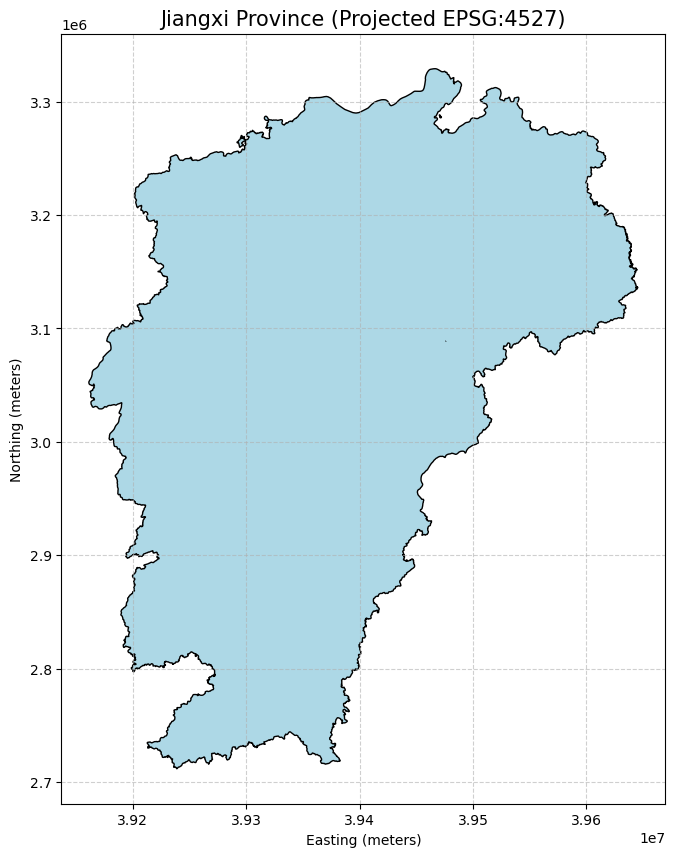

In [2]:
# Author: Anora Wu
# Date: Jan 7th 2026
# Construct the geographical 5km by 5km grids for Jiangxi Province

import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon
from shapely.geometry import box


# Change to your rawdata directory
os.chdir('/Users/anora/Team MG Dropbox/Wanru Wu/Cloudseeding_Anora')

# Load and project JX polygon to EPSG:4527 
jx_poly = gpd.read_file('jiangxi/jiangxi_shape.shp').geometry.iloc[0]
jx_poly_proj = gpd.GeoSeries([jx_poly], crs="EPSG:4326").to_crs("EPSG:4527").iloc[0]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the projected province
# We wrap it in a GeoSeries to use the built-in .plot() method
gpd.GeoSeries([jx_poly_proj]).plot(ax=ax, color='lightblue', edgecolor='black')

# Add titles and labels
ax.set_title("Jiangxi Province (Projected EPSG:4527)", fontsize=15)
ax.set_xlabel("Easting (meters)")
ax.set_ylabel("Northing (meters)")

# Show gridlines for better spatial reference
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [9]:
-0.2//2

-1.0

In [36]:

# Author: Anora Wu
# Date: Jan 7th 2026
# Construct a panel data, with each day between 2020-2025 being the time variable and each grid being the identity. 
# Each identity has a geometry and a id. 
# Fill in the cloud seeding operation day and location into the time slots and the grid 

import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
from shapely.geometry import box
from pyproj import Transformer


# Change to your rawdata directory
os.chdir('/Users/anora/Team MG Dropbox/Wanru Wu/Cloudseeding_Anora')

### CONSTRUCT GRID ###

# Load and project JX polygon to EPSG:4527 
jx_poly = gpd.read_file('jiangxi/jiangxi_shape.shp').geometry.iloc[0]
jx_poly_proj = gpd.GeoSeries([jx_poly], crs="EPSG:4326").to_crs("EPSG:4527").iloc[0]

# Calculate the bound of JX province            
minx, miny, maxx, maxy = jx_poly_proj.bounds              

# Bins for grid
grid_size = 5000
x_bins = np.arange(minx, maxx + grid_size, grid_size)
y_bins = np.arange(miny, maxy + grid_size, grid_size)

polygons = []
for i in range(len(y_bins)-1):
    for j in range(len(x_bins)-1):
        # create 5km * 5km grids
        poly = box(x_bins[j], y_bins[i], x_bins[j+1], y_bins[i+1])
        polygons.append({
            "cell_id": f"{i}_{j}",
            "geometry": poly,
            "cell_y": i,
            "cell_x": j
        })

jx_grid = gpd.GeoDataFrame(polygons, crs="EPSG:4527")

# Filtering out grids outside JX
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in intersects")
    jx_grid = jx_grid[jx_grid.geometry.intersects(jx_poly_proj)]

# Save as GeoPackage 
jx_grid.to_file("jiangxi/jx_grid.gpkg", layer='grid', driver="GPKG")

# Save as CSV for later use
df = pd.DataFrame(jx_grid.drop(columns='geometry'))
df.to_csv("jiangxi/jx_grid.csv", index=False)


### FILL IN OPERATION DATA ###

operation_data = pd.read_csv('operation/cleaned_data.csv')

# Correct one mistake in the data
condition = (operation_data['date'] == "2022-10-27") & (operation_data['start_time'] == "09:42") & (operation_data['city_o'] == "九江市")
operation_data.loc[condition, 'lon'] = 115.56
operation_data.loc[condition, 'lat'] = 29.043

# Add year and day of year to operation data
operation_data['date'] = pd.to_datetime(operation_data['date'])
operation_data['day'] = operation_data['date'].dt.dayofyear
operation_data['year'] = operation_data['date'].dt.year

# Transfer lat and lon to "EPSG:4527"
transformer = Transformer.from_crs("EPSG:4326", "EPSG:4527", always_xy=True)
operation_data['xs'], operation_data['ys'] = transformer.transform(
    operation_data['lon'].values, 
    operation_data['lat'].values
)

# For each day, fill in operation location into the grid
# Iterate over each day
results = []

operation_data['cell_x'] = (np.array(operation_data['xs'])-minx)//grid_size 
operation_data['cell_y'] = (np.array(operation_data['ys'])-miny)//grid_size 



In [37]:
a = operation_data[operation_data['cell_x'].isna()]
a

,Unnamed: 0,date,start_time,end_time,city_o,county_o,tool,num,weather_before,weather_after,...,num_rocket,num_cigar,num_other,location_o,day,year,xs,ys,cell_x,cell_y


In [29]:
a['lon'],a['lat']

(2290    29.043
 Name: lon, dtype: float64,
 2290    115.56
 Name: lat, dtype: float64)

In [ ]:
transformer.transform(29.043, 115.56)

/opt/anaconda3/envs/cloudseeding/lib/python3.9/site-packages/pyproj/transformer.py:820: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return self._transformer._transform_point(


(array([inf]), array([inf]))

In [38]:
# Author: Anora Wu
# Date: Jan 7th 2026
# Construct a panel data, with each day between 2020-2025 being the time variable and each grid being the identity. 
# Each identity has a geometry and a id. 
# Fill in the cloud seeding operation day and location into the time slots and the grid 

import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
from shapely.geometry import box
from pyproj import Transformer


# Change to your rawdata directory
os.chdir('/Users/anora/Team MG Dropbox/Wanru Wu/Cloudseeding_Anora')

### CONSTRUCT GRID ###

# Load and project JX polygon to EPSG:4527 
jx_poly = gpd.read_file('jiangxi/jiangxi_shape.shp').geometry.iloc[0]
jx_poly_proj = gpd.GeoSeries([jx_poly], crs="EPSG:4326").to_crs("EPSG:4527").iloc[0]

# Calculate the bound of JX province            
minx, miny, maxx, maxy = jx_poly_proj.bounds              

# Bins for grid
grid_size = 5000
x_bins = np.arange(minx, maxx + grid_size, grid_size)
y_bins = np.arange(miny, maxy + grid_size, grid_size)

polygons = []
for i in range(len(y_bins)-1):
    for j in range(len(x_bins)-1):
        # create 5km * 5km grids
        poly = box(x_bins[j], y_bins[i], x_bins[j+1], y_bins[i+1])
        polygons.append({
            "cell_id": f"{i}_{j}",
            "geometry": poly,
            "cell_y": i,
            "cell_x": j
        })

jx_grid = gpd.GeoDataFrame(polygons, crs="EPSG:4527")

# Filtering out grids outside JX
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in intersects")
    jx_grid = jx_grid[jx_grid.geometry.intersects(jx_poly_proj)]

# Save as GeoPackage 
jx_grid.to_file("jiangxi/jx_grid.gpkg", layer='grid', driver="GPKG")

# Save as CSV for later use
df = pd.DataFrame(jx_grid.drop(columns='geometry'))
df.to_csv("jiangxi/jx_grid.csv", index=False)


### FILL IN OPERATION DATA ###

operation_data = pd.read_csv('operation/cleaned_data.csv')

# Correct one mistake in the data
condition = (operation_data['date'] == "2022-10-27") & (operation_data['start_time'] == "09:42") & (operation_data['city_o'] == "九江市")
operation_data.loc[condition, 'lon'] = 115.56
operation_data.loc[condition, 'lat'] = 29.043

# Add year and day of year to operation data
operation_data['date'] = pd.to_datetime(operation_data['date'])
operation_data['day'] = operation_data['date'].dt.dayofyear
operation_data['year'] = operation_data['date'].dt.year

# Transfer lat and lon to "EPSG:4527"
transformer = Transformer.from_crs("EPSG:4326", "EPSG:4527", always_xy=True)
operation_data['xs'], operation_data['ys'] = transformer.transform(
    operation_data['lon'].values, 
    operation_data['lat'].values
)

operation_data['cell_x'] = (np.array(operation_data['xs'])-minx)//grid_size 
operation_data['cell_y'] = (np.array(operation_data['ys'])-miny)//grid_size 

operation_data['cell_id'] = (
    operation_data['cell_y'].astype(int).astype(str) + "_" + 
    operation_data['cell_x'].astype(int).astype(str)
)

# Construct panel
date_range = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
dates_df = pd.DataFrame({'date': date_range})

grid_ids = jx_grid[['cell_id']].copy()
dates_df['key'] = 1
grid_ids['key'] = 1
panel_df = pd.merge(dates_df, grid_ids, on='key').drop('key', axis=1)

In [43]:
panel_df

,date,cell_id
0,2020-01-01,0_14
1,2020-01-01,0_15
2,2020-01-01,0_16
3,2020-01-01,0_21
4,2020-01-01,0_41
...,...,...
15385643,2025-12-31,122_63
15385644,2025-12-31,123_59
15385645,2025-12-31,123_60
15385646,2025-12-31,123_61


In [42]:
2192*7019

15385648

In [45]:
import pandas as pd

# 1. Create a small set of dates
dates_df = pd.DataFrame({'date': ['2022-10-01', '2022-10-02']})

# 2. Create a small set of grid IDs
grid_ids = pd.DataFrame({'cell_id': ['A', 'B', 'C']})

# 3. Apply your logic (The "Key" Method)
dates_df['key'] = 1
grid_ids['key'] = 1
panel_df = pd.merge(dates_df, grid_ids, on='key').drop('key', axis=1)

print(panel_df)

         date cell_id
0  2022-10-01       A
1  2022-10-01       B
2  2022-10-01       C
3  2022-10-02       A
4  2022-10-02       B
5  2022-10-02       C


In [46]:
# Author: Anora Wu
# Date: Jan 7th 2026
# Construct a panel data, with each day between 2020-2025 being the time variable and each grid being the identity. 
# Each identity has a geometry and a id. 
# Fill in the cloud seeding operation day and location into the time slots and the grid 

import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
from shapely.geometry import box
from pyproj import Transformer


# Change to your rawdata directory
os.chdir('/Users/anora/Team MG Dropbox/Wanru Wu/Cloudseeding_Anora')

### CONSTRUCT GRID ###

# Load and project JX polygon to EPSG:4527 
jx_poly = gpd.read_file('jiangxi/jiangxi_shape.shp').geometry.iloc[0]
jx_poly_proj = gpd.GeoSeries([jx_poly], crs="EPSG:4326").to_crs("EPSG:4527").iloc[0]

# Calculate the bound of JX province            
minx, miny, maxx, maxy = jx_poly_proj.bounds              

# Bins for grid
grid_size = 5000
x_bins = np.arange(minx, maxx + grid_size, grid_size)
y_bins = np.arange(miny, maxy + grid_size, grid_size)

polygons = []
for i in range(len(y_bins)-1):
    for j in range(len(x_bins)-1):
        # create 5km * 5km grids
        poly = box(x_bins[j], y_bins[i], x_bins[j+1], y_bins[i+1])
        polygons.append({
            "cell_id": f"{i}_{j}",
            "geometry": poly,
            "cell_y": i,
            "cell_x": j
        })

jx_grid = gpd.GeoDataFrame(polygons, crs="EPSG:4527")

# Filtering out grids outside JX
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in intersects")
    jx_grid = jx_grid[jx_grid.geometry.intersects(jx_poly_proj)]

# Save as GeoPackage 
jx_grid.to_file("jiangxi/jx_grid.gpkg", layer='grid', driver="GPKG")

# Save as CSV for later use
df = pd.DataFrame(jx_grid.drop(columns='geometry'))
df.to_csv("jiangxi/jx_grid.csv", index=False)


### FILL IN OPERATION DATA ###

operation_data = pd.read_csv('operation/cleaned_data.csv')

# Correct one mistake in the data
condition = (operation_data['date'] == "2022-10-27") & (operation_data['start_time'] == "09:42") & (operation_data['city_o'] == "九江市")
operation_data.loc[condition, 'lon'] = 115.56
operation_data.loc[condition, 'lat'] = 29.043

# Add year and day of year to operation data
operation_data['date'] = pd.to_datetime(operation_data['date'])
operation_data['day'] = operation_data['date'].dt.dayofyear
operation_data['year'] = operation_data['date'].dt.year

# Transfer lat and lon to "EPSG:4527"
transformer = Transformer.from_crs("EPSG:4326", "EPSG:4527", always_xy=True)
operation_data['xs'], operation_data['ys'] = transformer.transform(
    operation_data['lon'].values, 
    operation_data['lat'].values
)

operation_data['cell_x'] = (np.array(operation_data['xs'])-minx)//grid_size 
operation_data['cell_y'] = (np.array(operation_data['ys'])-miny)//grid_size 

operation_data['cell_id'] = (
    operation_data['cell_y'].astype(int).astype(str) + "_" + 
    operation_data['cell_x'].astype(int).astype(str)
)

# Construct panel
date_range = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
dates_df = pd.DataFrame({'date': date_range})

grid_ids = jx_grid[['cell_id']].copy()
dates_df['key'] = 1
grid_ids['key'] = 1
panel_df = pd.merge(dates_df, grid_ids, on='key').drop('key', axis=1)

# 4. 统计每天、每个网格的操作次数
op_counts = operation_data.groupby(['date', 'cell_id']).size().reset_index(name='op_count')
op_counts['date'] = pd.to_datetime(op_counts['date'])


In [50]:
op_counts

,date,cell_id,op_count
0,2020-01-07,115_46,1
1,2020-01-07,27_27,1
2,2020-01-07,41_15,1
3,2020-01-07,43_22,1
4,2020-01-07,43_33,1
...,...,...,...
8621,2025-10-21,57_32,1
8622,2025-10-21,58_30,1
8623,2025-10-21,68_13,1
8624,2025-10-21,93_41,1
